**Assignment 2- CNN**

In [1]:
# Import libraries - compatible with Keras 3.x
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
# Set TensorFlow random seed
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")

# Use keras (standalone) for Keras 3.x compatibility
import keras
from keras.datasets import mnist, cifar10 # type: ignore
from keras.models import Sequential # type: ignore
from keras.layers import Dense, Dropout, Flatten, Activation, Conv2D, MaxPooling2D, BatchNormalization # type: ignore
from keras.utils import to_categorical, image_dataset_from_directory # type: ignore
from keras.optimizers import SGD, Adam # type: ignore
import keras.backend as K # type: ignore

print(f"Keras version: {keras.__version__}")
print(f"NumPy version: {np.__version__}")
print("Using Keras 3.x - ImageDataGenerator replaced with tf.data and image utilities")

TensorFlow version: 2.19.1
Keras version: 3.6.0
NumPy version: 2.1.3
Using Keras 3.x - ImageDataGenerator replaced with tf.data and image utilities


In [2]:
# Create train and test dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f'Training data shape: {X_train.shape}')
print(f'Training labels shape: {y_train.shape}')
print(f'Test data shape: {X_test.shape}')
print(f'Test labels shape: {y_test.shape}')
print(f'Pixel value range: {X_train.min()} to {X_train.max()}')

# Let's look at the raw data values
print(np.unique(X_train[0]))  # Print the pixel values of the first training image

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)
Pixel value range: 0 to 255
[  0   1   2   3   9  11  14  16  18  23  24  25  26  27  30  35  36  39
  43  45  46  49  55  56  64  66  70  78  80  81  82  90  93  94 107 108
 114 119 126 127 130 132 133 135 136 139 148 150 154 156 160 166 170 171
 172 175 182 183 186 187 190 195 198 201 205 207 212 213 219 221 225 226
 229 238 240 241 242 244 247 249 250 251 252 253 255]


1.a. start with creating a visualization of your input data

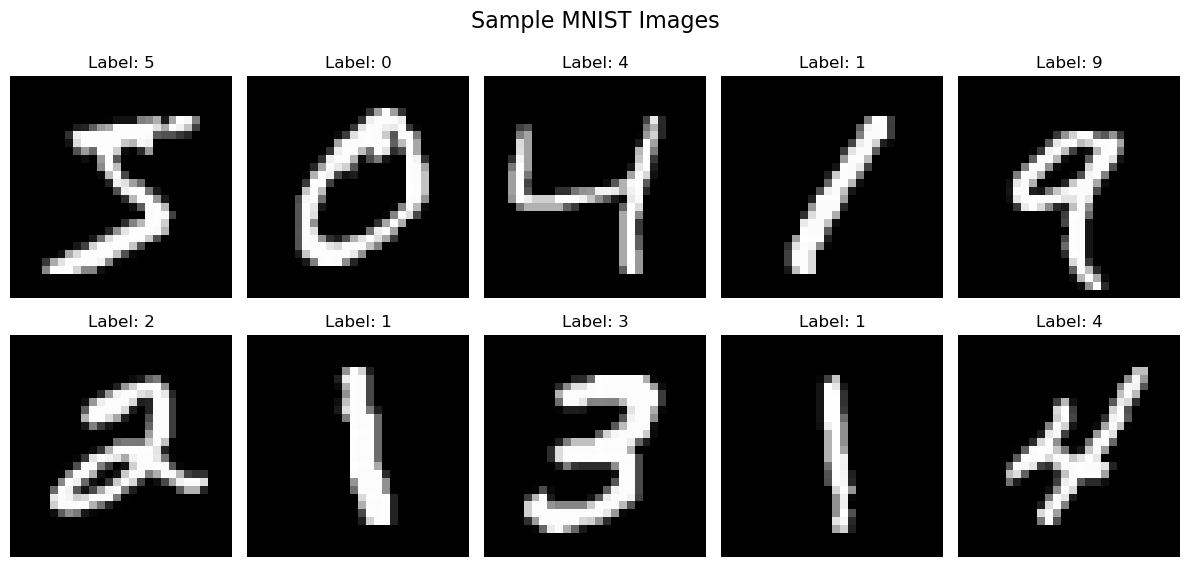

Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


In [3]:
#1.a. Create the visualization here
# Let's look into the dataset by visualizing some data points

# Plot some sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample MNIST Images', fontsize=16)

for i in range(10):
    row = i // 5
    col = i % 5
    axes[row, col].imshow(X_train[i], cmap='gray')
    axes[row, col].set_title(f'Label: {y_train[i]}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# Print some statistics
print(f'Number of classes: {len(np.unique(y_train))}')
print(f'Classes: {np.unique(y_train)}')

In [4]:
# Preprocessing
# Keras allows us to add the number of channels either to the beginning of shape or the end of it

# Extract image dimensions from the data itself. This is a more dynamic approach that hardcoding information that
# is already known.
img_rows, img_cols = X_train.shape[1], X_train.shape[2]

# Changed to use np.newaxis for clarity
if K.image_data_format() == 'channels_first':
    print("Using channels_first format")
    # Add channel dimension at position 1: (batch, 1, height, width)
    X_train = X_train[:, np.newaxis, :, :]
    X_test = X_test[:, np.newaxis, :, :]
    input_shape = (1, img_rows, img_cols)
else:
    print(f'Keras backend is: {K.image_data_format()}')
    print("Using channels_last format")
    # Add channel dimension at the end: (batch, height, width, 1)
    X_train = X_train[..., np.newaxis]
    X_test = X_test[..., np.newaxis]
    input_shape = (img_rows, img_cols, 1)

print(f'Training data shape: {X_train.shape}')
print(f'Training labels shape: {y_train.shape}')
print(f'Test data shape: {X_test.shape}')
print(f'Test labels shape: {y_test.shape}')
print(f'Input shape for CNN: {input_shape}')
print(f'Pixel value range: {X_train.min()} to {X_train.max()}')

# Let's look at the raw data values
print(f'Sample pixel values from first image: {np.unique(X_train[0])[:10]}...')  # Show first 10 unique values

Keras backend is: channels_last
Using channels_last format
Training data shape: (60000, 28, 28, 1)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28, 1)
Test labels shape: (10000,)
Input shape for CNN: (28, 28, 1)
Pixel value range: 0 to 255
Sample pixel values from first image: [ 0  1  2  3  9 11 14 16 18 23]...


In [5]:
# Apply preprocessing to X and y

# normalize inputs from 0-255 to 0-1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f'Normalized pixel value range: Train => {X_train.min():.3f} to {X_train.max():.3f}')
print(f'Normalized pixel value range: Test => {X_test.min():.3f} to {X_test.max():.3f}')

# Encode outputs (one-hot encoding)
num_classes = 10
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

print(f'Training labels shape after one-hot encoding: {y_train.shape}')
print(f'Test labels shape after one-hot encoding: {y_test.shape}')
print(f'Sample encoded label: {y_train[0]}')

Normalized pixel value range: Train => 0.000 to 1.000
Normalized pixel value range: Test => 0.000 to 1.000
Training labels shape after one-hot encoding: (60000, 10)
Test labels shape after one-hot encoding: (10000, 10)
Sample encoded label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


1.b. Create a CNN model with 4 convolution layers in which two of them have 32 and two of them have 64 filters. The fully connected layer has one hidden layer (512 nodes). Draw the Learning curve. What is your understanding from learning curve? Batch size=128 and epochs=20

In [6]:
#1.b.
# Create CNN model with 4 convolution layers (2x32 filters, 2x64 filters)
# Fully connected layer with one hidden layer (512 nodes)

model = Sequential()

# 1st convolution layer - 32 filters
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 2nd convolution layer - 32 filters  
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 3rd convolution layer - 64 filters. Choose padding solution to maintain spatial dimensions.
# Why padding='same' is best solution:
# - Maintains assignment requirements - still 4 convolution layers as specified
# - Standard practice - most modern CNNs use same padding
# - Preserves learning capacity - keeps spatial feature extraction
# - Minimal impact - small computational overhead
# - Prevents dimension collapse - allows the network to learn effectively
# The error occurs because after 3 MaxPooling layers (each halving dimensions), 
# the 28×28 input becomes very small, and the 4th conv layer without padding tries 
# to apply a 3×3 kernel to insufficient spatial dimensions.
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 4th convolution layer - 64 filters (add padding='same' to prevent negative output size)
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))

# Flatten the output from convolutional layers
model.add(Flatten())

# Fully connected layer with 512 nodes
model.add(Dense(512, activation='relu'))

# Output layer for 10 classes
model.add(Dense(num_classes, activation='softmax'))

# Print model summary
print("MNIST CNN Model Summary:")
model.summary()

MNIST CNN Model Summary:


/Users/marston.ward/miniforge3/envs/pytorch/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-11-01 16:56:29.430065: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-11-01 16:56:29.430170: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-11-01 16:56:29.430179: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
I0000 00:00:1762034189.430663  334404 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1762034189.431619  334404 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 5, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 2, 2, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,706 (787.91 KB)

 Trainable params: 201,706 (787.91 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Check Apple Silicon GPU availability (Metal backend)
print("Apple Silicon GPU Information:")
print(f"TensorFlow version: {tf.__version__}")
print(f"TensorFlow built with CUDA: {tf.test.is_built_with_cuda()}")

# Check for Apple Silicon GPU (Metal)
physical_devices = tf.config.list_physical_devices()
print(f"All physical devices: {physical_devices}")

gpu_devices = tf.config.list_physical_devices('GPU')
print(f"GPU devices: {gpu_devices}")

# Check for Apple Silicon specific devices
try:
    # For Apple Silicon, TensorFlow uses Metal backend
    logical_gpus = tf.config.experimental.list_logical_device_configuration(gpu_devices[0]) if gpu_devices else None
    print(f"Logical GPU config: {logical_gpus}")
except:
    print("No GPU configuration available")

if gpu_devices:
    print("✅ Apple Silicon GPU detected - training will use Metal acceleration")
    print(f"GPU device: {gpu_devices[0]}")
    
    # Enable memory growth for Apple Silicon GPU
    try:
        for gpu in gpu_devices:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ Memory growth enabled for GPU")
    except Exception as e:
        print(f"Note: {e}")
else:
    print("⚠️ No GPU detected - training will use CPU")
    
# Test GPU with a simple operation
try:
    with tf.device('/GPU:0'):
        a = tf.constant([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
        b = tf.constant([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])
        c = tf.matmul(a, b)
        print("✅ GPU test operation successful")
        print(f"Test result shape: {c.shape}")
except Exception as e:
    print(f"GPU test failed: {e}")
    print("Will use CPU for training")

Apple Silicon GPU Information:
TensorFlow version: 2.19.1
TensorFlow built with CUDA: False
All physical devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
No GPU configuration available
✅ Apple Silicon GPU detected - training will use Metal acceleration
GPU device: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Note: Physical devices cannot be modified after being initialized
✅ GPU test operation successful
Test result shape: (2, 2)


In [8]:
# Debug: Check current data shapes
print("Current data shapes:")
print(f"X_train.shape: {X_train.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"X_test.shape: {X_test.shape}")
print(f"y_test.shape: {y_test.shape}")

Current data shapes:
X_train.shape: (60000, 28, 28, 1)
y_train.shape: (60000, 10)
X_test.shape: (10000, 28, 28, 1)
y_test.shape: (10000, 10)


In [9]:
# Fix: Reload and reprocess data correctly
print("Reloading and preprocessing MNIST data...")

# Reload fresh data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Add channel dimension (only once!)
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

# Normalize
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# One-hot encode (only once!)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("After correct preprocessing:")
print(f"X_train.shape: {X_train.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"X_test.shape: {X_test.shape}")
print(f"y_test.shape: {y_test.shape}")
print("✅ Data shapes are now correct for training!")

Reloading and preprocessing MNIST data...
After correct preprocessing:
X_train.shape: (60000, 28, 28, 1)
y_train.shape: (60000, 10)
X_test.shape: (10000, 28, 28, 1)
y_test.shape: (10000, 10)
✅ Data shapes are now correct for training!


In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model with batch_size=128 and epochs=20 as specified
batch_size = 128
epochs = 20

print(f"Training with batch_size={batch_size} and epochs={epochs}")
print(f"Using seed={SEED} for reproducible shuffling")

hist = model.fit(X_train, y_train,
                 batch_size=batch_size,
                 epochs=epochs,
                 verbose=1,
                 validation_data=(X_test, y_test),
                 shuffle=True)  # Shuffle is True by default, but explicit for clarity

Training with batch_size=128 and epochs=20
Using seed=42 for reproducible shuffling
Epoch 1/20


2025-11-01 16:56:58.504764: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8219 - loss: 0.5767 - val_accuracy: 0.9780 - val_loss: 0.0632
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8219 - loss: 0.5767 - val_accuracy: 0.9780 - val_loss: 0.0632
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9779 - loss: 0.0727 - val_accuracy: 0.9879 - val_loss: 0.0395
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9779 - loss: 0.0727 - val_accuracy: 0.9879 - val_loss: 0.0395
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9862 - loss: 0.0454 - val_accuracy: 0.9820 - val_loss: 0.0574
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9862 - loss: 0.0454 - val_accuracy: 0.9820 - val_loss: 0.0574
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9896 - loss: 0.0332 - val_accuracy: 0.9819 - val_loss: 0.0598
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9896 - loss: 0.0332 - val_accuracy: 0.981

In [ ]:
# Measure test accuracy
scores = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {scores[0]:.4f}")
print(f"Test Accuracy: {scores[1]*100:.2f}%")

In [ ]:
# Draw Learning curve
def learning_curve(hist):
    """Create a function to draw learning curves"""
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(hist.history['accuracy'], label='Training Accuracy')
    plt.plot(hist.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True)
    
    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(hist.history['loss'], label='Training Loss')
    plt.plot(hist.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

learning_curve(hist)

In [ ]:
## What is your understanding from the learning curve?
# The valiidation accuracy is worse than the training accuracy but they both increase over time. 
# The loss decreaes over time for both training and validation, but the validation loss curve is consistently higher than the training curve. 
# This indicates some overfitting going on as the model behaves poorly on unseen data compared to training data. This could mean the model is
# memorizing training data patterns that do not generalize well, or at least as well as the test data given that the test accuracy plateaus around 98% while training accuracy approaches 100%.
# Some tips for fighting overfitting include:
# - Get more data (or data augmentation)
# - Dropout (see paper, explanation, dropout for cnns)
# - DropConnect
# - Regularization (see my masters thesis, page 85 for examples)
# - Feature scale clipping
# - Global average pooling
# - Make network smaller
# - Early stopping

**Part 2- CIFAR10**

In [ ]:
(X_train, y_train), (X_test, y_test) = # Load CIFAR 10 data here
labels= ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]
print(X_train.shape)
print(X_test.shape)

In [ ]:
# 2.a. Let's look into the dataset by visualizing some data points
# Plot the first 9 images from the CIFAR-10 dataset as specified

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle('First 9 CIFAR-10 Images', fontsize=16)

for i in range(9):
    row = i // 3
    col = i % 3
    axes[row, col].imshow(X_train_cifar[i])
    axes[row, col].set_title(f'Label: {labels[y_train_cifar[i][0]]}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# Print some statistics
print(f'Number of classes: {len(labels)}')
print(f'Image shape: {X_train_cifar[0].shape}')
print(f'Pixel value range: {X_train_cifar.min()} to {X_train_cifar.max()}')


2.b. Apply the pre-processing algorithms that we discussed last week. The augmented images are supposed to be seared by 20%, zoomed by 20% and horizontally flipped. Now, design a CNN model with 4 convolution layers in which two of them have 32 and two of them have 64 filters. The fully connected layer has two hidden layers (512 and 256 nodes respectively). Draw the Learning curve. What is your understanding from learning curve?

In [ ]:
# 2.b
# Preprocessing for CIFAR-10
# Normalize inputs from 0-255 to 0-1
X_train_cifar = X_train_cifar.astype('float32') / 255.0
X_test_cifar = X_test_cifar.astype('float32') / 255.0

# Encoding output (one-hot encoding)
num_classes_cifar = 10
y_train_cifar = to_categorical(y_train_cifar, num_classes_cifar)
y_test_cifar = to_categorical(y_test_cifar, num_classes_cifar)

print(f'CIFAR-10 normalized pixel range: {X_train_cifar.min():.1f} to {X_train_cifar.max():.1f}')
print(f'CIFAR-10 labels shape after encoding: {y_train_cifar.shape}')

# Create data augmentation - using tf.data for Keras 3.x compatibility
# Augmented images: sheared by 20%, zoomed by 20%, horizontally flipped
# Adding seed parameter for reproducible augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.2, seed=SEED),  # 20% rotation (shear effect)
    tf.keras.layers.RandomZoom(0.2, seed=SEED),      # 20% zoom
    tf.keras.layers.RandomFlip("horizontal", seed=SEED), # horizontal flip
], name="data_augmentation")

print(f"✅ Data augmentation configured with seed={SEED}")

# Create CIFAR-10 CNN model with 4 convolution layers (2x32, 2x64 filters)
# Two hidden layers (512 and 256 nodes)
model_cifar = tf.keras.Sequential([
    # Data augmentation layer
    data_augmentation,
    
    # First convolution layer - 32 filters
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Second convolution layer - 32 filters
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Third convolution layer - 64 filters
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Fourth convolution layer - 64 filters
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    
    # Flatten
    tf.keras.layers.Flatten(),
    
    # First hidden layer - 512 nodes
    tf.keras.layers.Dense(512, activation='relu'),
    
    # Second hidden layer - 256 nodes
    tf.keras.layers.Dense(256, activation='relu'),
    
    # Output layer
    tf.keras.layers.Dense(num_classes_cifar, activation='softmax')
])

# Compile model with SGD optimizer as specified
# Learning rate=0.005, decay=1x10-6, momentum=0.9
optimizer = SGD(learning_rate=0.005, decay=1e-6, momentum=0.9)
model_cifar.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

print("\nCIFAR-10 Model Summary:")
model_cifar.summary()

# Train the model
batch_size = 128
epochs = 20

print(f"Training CIFAR-10 model with seed={SEED} for reproducible results")

hist_cifar = model_cifar.fit(X_train_cifar, y_train_cifar,
                             batch_size=batch_size,
                             epochs=epochs,
                             verbose=1,
                             validation_data=(X_test_cifar, y_test_cifar),
                             shuffle=True)  # Shuffle is True by default, but explicit for clarity

In [ ]:
# Draw learning curve for CIFAR-10
learning_curve(hist_cifar)

In [ ]:
# What is the issue and possible solution for this learning curve?

In [ ]:
#2.c. Solution to resolve overfitting
# One solution is adding drop out
# Implement your solution here and train model

In [ ]:
# Draw learning curve
learning_curve(hist)

In [ ]:
# 2.d- This part is up to you to choose proper pre-trained model
# I chose VGG16 and RESNet50
# Implementing VGG16
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input
from keras.models import Model

vgg_model =
vgg_model.compile()   #Compile VGG16 model
hist =


In [ ]:
learning_curve(hist)

In [ ]:
vgg_model.evaluate(X_test, y_test, batch_size=256, verbose=1)

In [ ]:
# This is my second pre-trained model
from keras.applications.resnet50 import ResNet50
from keras.layers import GlobalAveragePooling2D

base_model = ResNet50()

# Let's train the model using RMSprop
model.compile
hist=

In [ ]:
learning_curve(hist)